In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from collections import Counter
import optuna
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="white", palette="muted")

In [2]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22593 entries, 0 to 22592
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          22593 non-null  int64 
 1   NCBIGeneID          22593 non-null  int64 
 2   Symbol              22593 non-null  object
 3   Description         22593 non-null  object
 4   GeneType            22593 non-null  object
 5   GeneGroupMethod     22593 non-null  object
 6   NucleotideSequence  22593 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.2+ MB


In [4]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4577 entries, 0 to 4576
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          4577 non-null   int64 
 1   NCBIGeneID          4577 non-null   int64 
 2   Symbol              4577 non-null   object
 3   Description         4577 non-null   object
 4   GeneType            4577 non-null   object
 5   GeneGroupMethod     4577 non-null   object
 6   NucleotideSequence  4577 non-null   object
dtypes: int64(2), object(5)
memory usage: 250.4+ KB


In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8326 entries, 0 to 8325
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          8326 non-null   int64 
 1   NCBIGeneID          8326 non-null   int64 
 2   Symbol              8326 non-null   object
 3   Description         8326 non-null   object
 4   GeneType            8326 non-null   object
 5   GeneGroupMethod     8326 non-null   object
 6   NucleotideSequence  8326 non-null   object
dtypes: int64(2), object(5)
memory usage: 455.5+ KB


In [6]:
def preprocess_data(input_df, dataset_name):
    df_clean = input_df.copy()
    
    if 'Unnamed: 0' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Unnamed: 0'])
        
    df_clean = df_clean.rename(columns={
        'NCBIGeneID': 'gene_id',
        'Symbol': 'symbol',
        'Description': 'description',
        'GeneType': 'gene_type',
        'GeneGroupMethod': 'group_method',
        'NucleotideSequence': 'sequence'
    })
    
    df_clean['sequence'] = df_clean['sequence'].str.replace('<', '', regex=False)
    df_clean['sequence'] = df_clean['sequence'].str.replace('>', '', regex=False)
    df_clean['seq_length'] = df_clean['sequence'].apply(len)

    if df_clean.duplicated().sum() > 0:
        df_clean = df_clean.drop_duplicates().reset_index(drop=True)
        print(f"Duplicated records dropped in {dataset_name}.")
    else:
        print(f"There were no duplicates at all in {dataset_name}.")

        
    return df_clean


train_clean_df = preprocess_data(train_df, "train_df")
val_clean_df = preprocess_data(val_df, "val_df")
test_clean_df = preprocess_data(test_df, "test_df")

There were no duplicates at all in train_df.
There were no duplicates at all in val_df.
There were no duplicates at all in test_df.


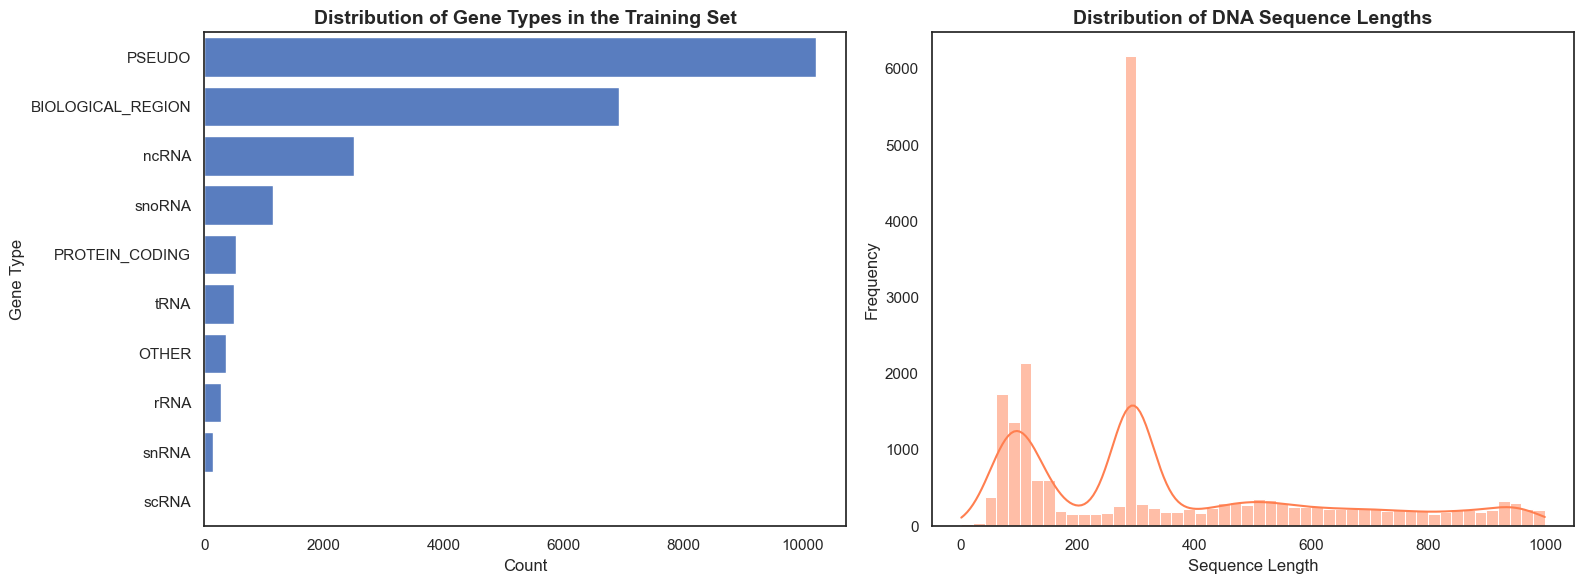

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=train_clean_df, y='gene_type', ax=axes[0], order=train_clean_df['gene_type'].value_counts().index)
axes[0].set_title('Distribution of Gene Types in the Training Set', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_ylabel('Gene Type', fontsize=12)

sns.histplot(data=train_clean_df, x='seq_length', bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of DNA Sequence Lengths', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sequence Length', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

> The distribution of **DNA sequence lengths is not normal at all**. There is a massive, brutal spike at exactly around 300 nucleotides. In bioinformatics, this is rarely a coincidence. This phenomenon can be attributed to two main factors:
1. Technological reason: DNA sequencing machines (such as Illumina) often output fixed-length "reads" (e.g., exactly 300 base pairs).
2. Biological reason: Certain highly repetitive genetic elements (like the ~300 base pair long Alu elements in the human genome) might dominate the dataset. If, for instance, all PSEUDO genes happen to be ~300 nucleotides long while other types vary, a "lazy" machine learning model wouldn't actually learn the DNA sequence patterns. It would simply measure the string length and guess the target class based on that alone. ==> Solution: `K-mer counting`


> On the other hand PSEUDO and BIOLOGICAL_REGION classes completely overshadow the other categories (for example, PROTEIN_CODING is almost invisible compared to them). ==> Solution: `ComplementNB`. Instead of calculating the probability that a sample belongs to a specific target class, Complement Naive Bayes calculates the probability that the sample does not belong to all the other (dominant) classes. This mathematically neutralizes the bias caused by the majority classes.

In [8]:
print("--- CLASS DISTRIBUTION IN VALIDATION SET ---")
val_class_counts = Counter(val_clean_df['gene_type'])

for gene_type, count in val_class_counts.most_common():
    print(f"{gene_type}: {count}")

--- CLASS DISTRIBUTION IN VALIDATION SET ---
PSEUDO: 2133
BIOLOGICAL_REGION: 1398
ncRNA: 516
snoRNA: 239
PROTEIN_CODING: 101
OTHER: 88
tRNA: 72
snRNA: 22
rRNA: 8


In [9]:
print("--- CLASS DISTRIBUTION IN TEST SET ---")
test_class_counts = Counter(test_clean_df['gene_type'])

for gene_type, count in test_class_counts.most_common():
    print(f"{gene_type}: {count}")

--- CLASS DISTRIBUTION IN TEST SET ---
PSEUDO: 3800
BIOLOGICAL_REGION: 2651
ncRNA: 894
snoRNA: 405
PROTEIN_CODING: 184
tRNA: 148
OTHER: 133
rRNA: 72
snRNA: 38
scRNA: 1


Vectorizing train data...
Vectorizing validation and test data...
Feature matrix shape (Train): (22593, 2444194)
Number of unique 11-mers generated: 2444194
------------------------------------------------------------

Classification Report:

                   precision    recall  f1-score   support

BIOLOGICAL_REGION       0.90      0.93      0.91      2651
            OTHER       0.95      0.92      0.93       133
   PROTEIN_CODING       0.86      0.54      0.67       184
           PSEUDO       0.91      0.94      0.93      3800
            ncRNA       0.99      0.76      0.86       894
             rRNA       0.81      1.00      0.89        72
            scRNA       0.00      0.00      0.00         1
            snRNA       0.89      0.21      0.34        38
           snoRNA       0.86      0.94      0.90       405
             tRNA       0.82      0.98      0.90       148

         accuracy                           0.91      8326
        macro avg       0.80      0.72      0.7

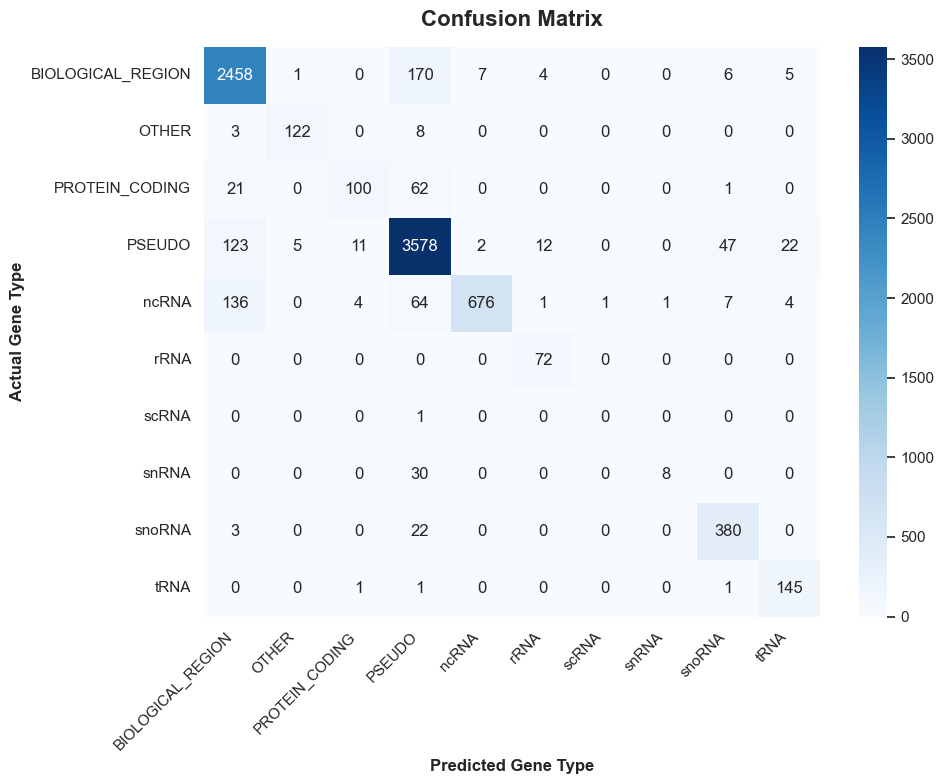

In [10]:
kmer_size = 11
vectorizer = TfidfVectorizer(
    analyzer='char', 
    ngram_range=(kmer_size, kmer_size), 
    use_idf=False, 
    norm='l1'
)

# Fit the vectorizer ONLY on the Training set, then transform all sets
print("Vectorizing train data...")
X_train_vec = vectorizer.fit_transform(train_clean_df['sequence'])
y_train = train_clean_df['gene_type']

print("Vectorizing validation and test data...")
X_val_vec = vectorizer.transform(val_clean_df['sequence'])
y_val = val_clean_df['gene_type']
X_test_vec = vectorizer.transform(test_clean_df['sequence'])
y_test = test_clean_df['gene_type']



print(f"Feature matrix shape (Train): {X_train_vec.shape}")
print(f"Number of unique {kmer_size}-mers generated: {X_train_vec.shape[1]}")
print("-" * 60)

model = ComplementNB()
model.fit(X_train_vec, y_train)
y_pred_test = model.predict(X_test_vec)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_test))


plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_test)
classes = sorted(y_test.unique())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Gene Type', fontsize=12, fontweight='bold')
plt.ylabel('Actual Gene Type', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Vector Normalization:
After generating our K-mers (N-grams), we applied L1 normalization (Term Frequency) to the resulting vectors. This was a critical step because our DNA sequences varied wildly in length. Without normalization, a sequence of 10,000 nucleotides would naturally contain massively higher K-mer counts than a 100-nucleotide sequence. The model would falsely interpret these high raw counts as "higher importance." By converting raw counts into relative frequencies (e.g., stating that a specific 3-mer makes up 12% of the total sequence), we ensured that short and long sequences became perfectly comparable on the same mathematical scale.

[I 2026-04-26 13:18:29,667] A new study created in memory with name: no-name-1740a9f8-cadf-455f-8a0e-f7758e7e2f80


--- 1. HYPERPARAMETER TUNING WITH OPTUNA ---


[I 2026-04-26 13:18:39,653] Trial 0 finished with value: 0.8744220494715819 and parameters: {'kmer_size': 10, 'alpha': 0.01288004620599985, 'norm': False}. Best is trial 0 with value: 0.8744220494715819.
[I 2026-04-26 13:18:47,146] Trial 1 finished with value: 0.5672620113954457 and parameters: {'kmer_size': 9, 'alpha': 0.0001299376178158359, 'norm': True}. Best is trial 0 with value: 0.8744220494715819.
[I 2026-04-26 13:18:54,395] Trial 2 finished with value: 0.668527198472386 and parameters: {'kmer_size': 9, 'alpha': 0.06977377004473158, 'norm': True}. Best is trial 0 with value: 0.8744220494715819.
[I 2026-04-26 13:19:00,466] Trial 3 finished with value: 0.6731432803427473 and parameters: {'kmer_size': 8, 'alpha': 0.0006332442452208317, 'norm': True}. Best is trial 0 with value: 0.8744220494715819.
[I 2026-04-26 13:19:06,340] Trial 4 finished with value: 0.6735755423314163 and parameters: {'kmer_size': 8, 'alpha': 0.0014291642013273989, 'norm': True}. Best is trial 0 with value: 0.8


--- OPTUNA TUNING COMPLETED ---
Best hyperparameters found:
  kmer_size: 11
  alpha: 0.0002660364640609893
  norm: False
Best Validation Macro F1-Score: 0.9673
------------------------------------------------------------

--- 2. FINAL MODEL TRAINING AND EVALUATION (TEST SET) ---
Applying the best vectorizer (k=11) to Train and Test sets...
Training the final ComplementNB model...

Final Evaluation (Test Set):

                   precision    recall  f1-score   support

BIOLOGICAL_REGION       0.94      0.98      0.96      2651
            OTHER       0.97      0.97      0.97       133
   PROTEIN_CODING       0.94      0.81      0.87       184
           PSEUDO       0.96      0.98      0.97      3800
            ncRNA       1.00      0.85      0.92       894
             rRNA       0.92      1.00      0.96        72
            scRNA       0.00      0.00      0.00         1
            snRNA       0.93      0.66      0.77        38
           snoRNA       0.95      0.97      0.96     

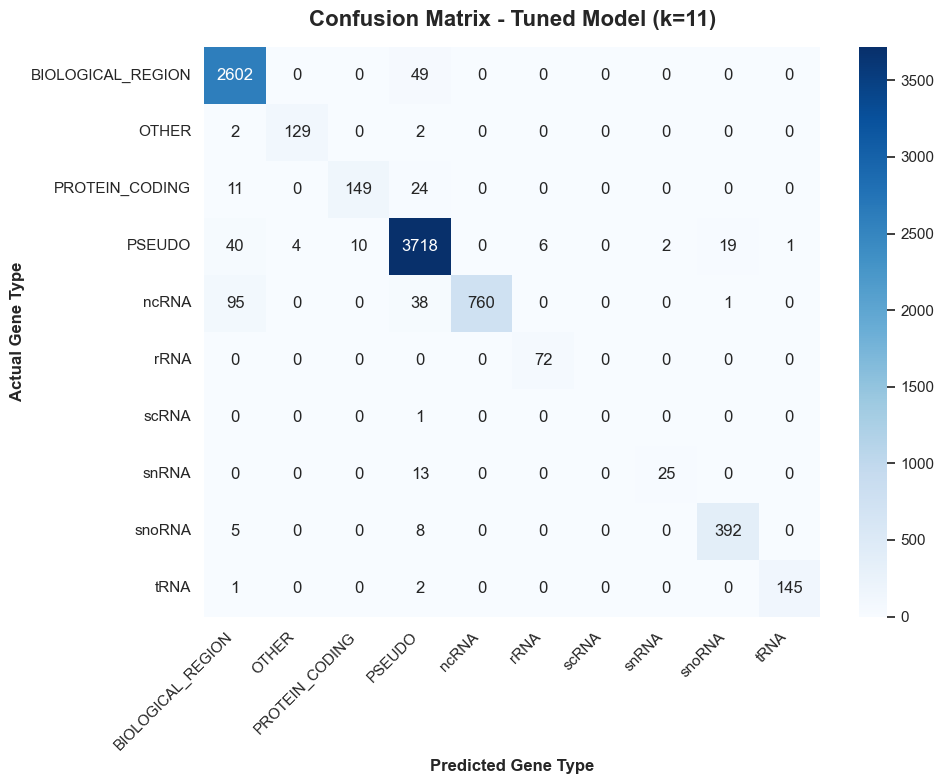

In [11]:
print("--- 1. HYPERPARAMETER TUNING WITH OPTUNA ---")

def objective(trial):
    # 1. Suggested parameters for Vectorizer and Model
    kmer_size = trial.suggest_int('kmer_size', 7, 11)
    alpha = trial.suggest_float('alpha', 1e-5, 1.0, log=True)
    norm = trial.suggest_categorical('norm', [True, False])
    
    # 2. Vectorize Data (Train and Validation)
    vectorizer = TfidfVectorizer(
        analyzer='char', 
        ngram_range=(kmer_size, kmer_size), 
        use_idf=False, 
        norm='l1'
    )
    
    X_train_vec = vectorizer.fit_transform(train_clean_df['sequence'])
    X_val_vec = vectorizer.transform(val_clean_df['sequence'])
    
    # 3. Train Model
    model = ComplementNB(alpha=alpha, norm=norm)
    model.fit(X_train_vec, train_clean_df['gene_type'])
    
    # 4. Evaluate on Validation Set
    y_val_pred = model.predict(X_val_vec)
    
    # We optimize for MACRO F1-SCORE, not ACCURACY!
    macro_f1 = f1_score(val_clean_df['gene_type'], y_val_pred, average='macro')
    
    return macro_f1


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15) 

print("\n--- OPTUNA TUNING COMPLETED ---")
print("Best hyperparameters found:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print(f"Best Validation Macro F1-Score: {study.best_value:.4f}")
print("-" * 60)


print("\n--- 2. FINAL MODEL TRAINING AND EVALUATION (TEST SET) ---")
best_k = study.best_params['kmer_size']
print(f"Applying the best vectorizer (k={best_k}) to Train and Test sets...")
final_vectorizer = TfidfVectorizer(
    analyzer='char', 
    ngram_range=(best_k, best_k), 
    use_idf=False, 
    norm='l1'
)

X_train_final = final_vectorizer.fit_transform(train_clean_df['sequence'])
X_test_final = final_vectorizer.transform(test_clean_df['sequence'])

# Re-train the model with the BEST parameters
print("Training the final ComplementNB model...")
final_model = ComplementNB(
    alpha=study.best_params['alpha'], 
    norm=study.best_params['norm']
)

final_model.fit(X_train_final, train_clean_df['gene_type'])
y_test_pred = final_model.predict(X_test_final)



print("\nFinal Evaluation (Test Set):\n")
print(classification_report(test_clean_df['gene_type'], y_test_pred))


plt.figure(figsize=(10, 8))
cm_final = confusion_matrix(test_clean_df['gene_type'], y_test_pred)
classes = sorted(test_clean_df['gene_type'].unique())

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title(f'Confusion Matrix - Tuned Model (k={best_k})', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Gene Type', fontsize=12, fontweight='bold')
plt.ylabel('Actual Gene Type', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Optuna Tuning & Maximizing the Macro F1-Score:
During hyperparameter optimization with Optuna, we deliberately chose to maximize the Macro F1-score rather than global Accuracy. In highly imbalanced datasets, Accuracy is a deceptive metric; a model could achieve over 90% simply by predicting the majority class every single time while ignoring the rare classes. The Macro F1-score forces the model to treat every class equally. Thanks to this approach, we achieved a beautiful performance boost across the board, significantly improving the recall rates of minority classes like snRNA and PROTEIN_CODING.

### The scRNA Anomaly (~ Dataset Limitation):
Despite the overall excellent performance, the model failed to correctly classify the scRNA category. However, a deeper dive into the data distribution proves this is an inherent flaw in the dataset, not a failure of our model. There were exactly zero scRNA samples in the validation set, meaning Optuna had no mathematical way to see or optimize for it during tuning. Furthermore, the test set contained exactly one single scRNA sample. A machine learning model simply cannot recognize a pattern it was never given a fair opportunity to learn. This highlights a critical lack of diversity in the provided dataset for that specific class.